# Task 3.2 — Region Clustering (Simulated Annealing)

Partition the 434 NE county-equivalent units into **k = 50** demand-balanced, spatially
contiguous, compact regions aligned to major interstate/rail corridors using a Simulated
Annealing (SA) graph-partitioning heuristic.

**Core algorithms** live in `Task3/clustering.py`. This notebook handles:
- §3.2.1 Data loading & NE county subset
- §3.2.2 County adjacency graph construction
- §3.2.3 Infrastructure overlay (alignment metric)
- Call `clustering.py` for §3.2.4–3.2.7 (initialization, objective, constraints, SA loop)
- §3.2.8 Quality assessment & visualization

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
import numpy as np
import pandas as pd
from shapely.geometry import box

# Add Task3/ to path so clustering.py is importable
sys.path.insert(0, str(Path(".").resolve()))
import clustering

PROJ_ROOT = Path("..").resolve()
DATA3 = PROJ_ROOT / "Data" / "Task3"
RAW_DIR = DATA3 / "raw"
RAW_CENSUS_DIR = RAW_DIR / "census_counties"
RAW_ROADS_DIR = RAW_DIR / "roads"
RAW_RAILS_DIR = RAW_DIR / "rails"
DERIVED_DIR = DATA3 / "derived"
CACHE_DIR = DATA3 / "cache"
FIGURES_DIR = DATA3 / "figures"
OUTPUTS_DIR = DATA3 / "outputs"

for path in [
    DATA3, RAW_DIR, RAW_CENSUS_DIR, RAW_ROADS_DIR, RAW_RAILS_DIR,
    DERIVED_DIR, CACHE_DIR, FIGURES_DIR, OUTPUTS_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

# 14 NE megaregion states
NE_STATES = {"WV", "VA", "MD", "DE", "DC", "PA", "NY", "NJ",
             "CT", "MA", "NH", "VT", "ME", "RI"}

# Target CRS: NAD27 / US National Atlas Equal Area (meters)
TARGET_CRS = "EPSG:9311"
TARGET_EPSG = 9311

print("Imports OK")

Imports OK


---
## 3.2.1 — Data Loading & NE County Subset

Load the 2023 Census county shapefile (EPSG:4269), filter to the 14 NE states,
and join `county_external_throughput.parquet` on `GEOID == fips` as the clustering demand weight.

**Demand weight for clustering** (hub-facing external demand):
$$W_i = \text{ext\_in}_i + \text{ext\_out}_i \quad (\text{NE-to-non-NE boundary flows, 2025 ktons})$$

Only flows between NE county $i$ and counties **outside** the NE megaregion are counted.
Intra-NE flows are excluded because a regional hub serves inter-region / external freight —
flow that stays within the same final region does not generate hub-facing demand.

The activity throughput (all-flow bidirectional) is retained as a secondary column
for visualization reference but is **not** passed to the SA algorithm.

Note: a post-assignment correction (`recompute_region_external_demand.py`) further removes
same-final-region flows to produce fully corrected hub-facing regional demand metrics.

Reproject to EPSG:9311 for distance/shared-border calculations.

In [2]:
PREPARED_PATH = DERIVED_DIR / "ne_counties_prepared.gpkg"
EXT_TP_PATH   = DERIVED_DIR / "county_external_throughput.parquet"
PREPARED_COLS = [
    "fips", "NAME", "STUSPS", "tons_in", "tons_out",
    "throughput", "centroid_x", "centroid_y", "geometry",
]

if PREPARED_PATH.exists():
    ne = gpd.read_file(PREPARED_PATH)
    print(f"Loaded cached ne_counties_prepared.gpkg  shape={ne.shape}")

    cached_epsg = ne.crs.to_epsg() if ne.crs else None
    needs_refresh = cached_epsg != TARGET_EPSG or any(col not in ne.columns for col in PREPARED_COLS)
    if needs_refresh:
        print(f"Refreshing cached counties to {TARGET_CRS} from {ne.crs}")
        ne = ne.to_crs(TARGET_CRS)
        centroids = ne.geometry.centroid
        ne["centroid_x"] = centroids.x
        ne["centroid_y"] = centroids.y
        ne = ne[PREPARED_COLS].reset_index(drop=True)
        ne.to_file(PREPARED_PATH, driver="GPKG")
        print(f"Updated ne_counties_prepared.gpkg  shape={ne.shape}")
    else:
        ne = ne[PREPARED_COLS].reset_index(drop=True)
else:
    # ── Load shapefile ────────────────────────────────────────────────────────
    shp_path = RAW_CENSUS_DIR / "cb_2023_us_county_500k.shp"
    counties = gpd.read_file(shp_path)[["GEOID", "NAME", "STUSPS", "geometry"]]
    counties["GEOID"] = counties["GEOID"].str.zfill(5)

    # ── Filter to NE megaregion ───────────────────────────────────────────────
    ne_raw = counties[counties["STUSPS"].isin(NE_STATES)].copy()
    print(f"NE counties (raw): {len(ne_raw)} rows")

    # ── Join activity throughput for gpkg cache (visualization column only) ───
    tp = pd.read_parquet(DERIVED_DIR / "county_activity_throughput.parquet")
    tp["fips"] = tp["fips"].astype(str).str.zfill(5)

    ne = ne_raw.merge(tp, left_on="GEOID", right_on="fips", how="left")
    ne["fips"] = ne["GEOID"]

    for col in ["tons_in", "tons_out", "throughput"]:
        ne[col] = ne[col].fillna(0.0)

    # ── Reproject to meters ───────────────────────────────────────────────────
    ne = ne.to_crs(TARGET_CRS)
    centroids = ne.geometry.centroid
    ne["centroid_x"] = centroids.x
    ne["centroid_y"] = centroids.y
    ne = ne[PREPARED_COLS].reset_index(drop=True)
    ne.to_file(PREPARED_PATH, driver="GPKG")
    print(f"Saved ne_counties_prepared.gpkg  shape={ne.shape}")

# ── Join external throughput as clustering demand weight ─────────────────────
# Hub-facing demand: NE-to-non-NE boundary flows only.
ext_tp = pd.read_parquet(EXT_TP_PATH)
ext_tp["fips"] = ext_tp["fips"].astype(str).str.zfill(5)
ne = ne.merge(ext_tp[["fips", "external_throughput"]], on="fips", how="left")
ne["external_throughput"] = ne["external_throughput"].fillna(0.0)
ne = ne.rename(columns={"external_throughput": "demand_weight"})

print(f"\nDemand weight (external throughput) joined:")
print(f"  demand_weight range: [{ne['demand_weight'].min():,.1f}, {ne['demand_weight'].max():,.1f}] k-tons")
print(f"  Zero-demand-weight counties: {(ne['demand_weight'] == 0).sum()}")

Loaded cached ne_counties_prepared.gpkg  shape=(434, 9)

Demand weight (external throughput) joined:
  demand_weight range: [40.1, 19,765.8] k-tons
  Zero-demand-weight counties: 0


In [3]:
# ── Sanity checks 3.2.1 ───────────────────────────────────────────────────────
assert len(ne) == 434, f"Expected 434 NE county units, got {len(ne)}"
assert ne["demand_weight"].isna().sum() == 0, "NaN demand_weight values found"
assert ne.crs.to_epsg() == TARGET_EPSG, f"Wrong CRS: {ne.crs}"
assert ne["fips"].nunique() == 434, "Duplicate FIPS codes detected"

print(f"✓ 434 NE county units loaded")
print(f"  Activity throughput (heatmap ref): [{ne['throughput'].min():,.1f}, {ne['throughput'].max():,.1f}] k-tons")
print(f"  Demand weight (external, clustering): [{ne['demand_weight'].min():,.1f}, {ne['demand_weight'].max():,.1f}] k-tons")
print(f"  Total demand weight: {ne['demand_weight'].sum():,.0f} k-tons")
print(f"  Zero-demand-weight counties: {(ne['demand_weight'] == 0).sum()}")
print(f"  States: {sorted(ne['STUSPS'].unique())}")

✓ 434 NE county units loaded
  Activity throughput (heatmap ref): [223.2, 71,002.1] k-tons
  Demand weight (external, clustering): [40.1, 19,765.8] k-tons
  Total demand weight: 447,344 k-tons
  Zero-demand-weight counties: 0
  States: ['CT', 'DC', 'DE', 'MA', 'MD', 'ME', 'NH', 'NJ', 'NY', 'PA', 'RI', 'VA', 'VT', 'WV']


---
## 3.2.2 — County Adjacency Graph

Rook-style adjacency: two counties are adjacent if their shared border length > 0 meters
(point-only corner contacts are excluded).

Island counties disconnected by geography are patched with synthetic operational links:

| County | State | Synthetic Link | Rationale |
|--------|-------|----------------|-----------|
| Dukes (25007) | MA | Bristol (25005) | ferry/bridge proxy |
| Nantucket (25019) | MA | Dukes (25007) | ferry proxy |
| Richmond (36085) | NY (Staten Island) | Kings (36047) | Verrazzano-Narrows Bridge |

These are flagged `synthetic_edge = True` in the edge list.

In [4]:
EDGES_PATH = CACHE_DIR / "ne_county_edges.parquet"

if EDGES_PATH.exists():
    edges_df = pd.read_parquet(EDGES_PATH)
    print(f"Loaded cached ne_county_edges.parquet  edges={len(edges_df)}")
else:
    print("Building adjacency graph from shared border intersections ...")
    print("(This may take 1–3 minutes on first run)")

    edge_rows = []
    fips_list = ne["fips"].tolist()
    geom_list = ne["geometry"].tolist()
    n = len(ne)

    # Build spatial index for fast neighbor lookup
    from shapely.strtree import STRtree
    tree = STRtree(geom_list)

    for i in range(n):
        geom_i = geom_list[i]
        candidates = tree.query(geom_i, predicate="intersects")
        for j in candidates:
            if j <= i:
                continue
            shared = geom_i.intersection(geom_list[j])
            # Only keep non-point contacts (LineString or MultiLineString)
            if shared.is_empty or shared.geom_type in ("Point", "MultiPoint"):
                continue
            border_len = shared.length   # meters in the target equal-area CRS
            if border_len <= 0:
                continue
            edge_rows.append({
                "fips_a": fips_list[i],
                "fips_b": fips_list[j],
                "shared_border_m": border_len,
                "interstate_km": 0.0,
                "rail_km": 0.0,
                "infra_weight": 0.0,
                "synthetic_edge": False,
            })

    # Synthetic operational links (island patches)
    SYNTHETIC_EDGES = [
        ("25007", "25005"),   # Dukes ↔ Bristol (MA, ferry proxy)
        ("25019", "25007"),   # Nantucket ↔ Dukes (MA, ferry proxy)
        ("36085", "36047"),   # Richmond ↔ Kings (NY, Verrazzano-Narrows Bridge)
    ]
    ne_fips_set = set(ne["fips"])
    for fa, fb in SYNTHETIC_EDGES:
        if fa in ne_fips_set and fb in ne_fips_set:
            edge_rows.append({
                "fips_a": fa, "fips_b": fb,
                "shared_border_m": 0.0,
                "interstate_km": 0.0, "rail_km": 0.0,
                "infra_weight": 0.0,
                "synthetic_edge": True,
            })

    edges_df = pd.DataFrame(edge_rows)
    edges_df.to_parquet(EDGES_PATH, index=False)
    print(f"Saved ne_county_edges.parquet  edges={len(edges_df)}")

Loaded cached ne_county_edges.parquet  edges=1096


In [5]:
# Build NetworkX graph (without infra weights yet — added in 3.2.3)
G = clustering.build_graph(edges_df)

# Sanity checks 3.2.2
n_components = nx.number_connected_components(G)
assert G.number_of_nodes() == 434, f"Graph has {G.number_of_nodes()} nodes, expected 434"
assert n_components == 1, (
    f"Graph has {n_components} connected components — add more synthetic edges"
)
synthetic_count = edges_df["synthetic_edge"].sum()

print(f"✓ Adjacency graph built")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()} (synthetic: {synthetic_count})")
print(f"  Connected components: {n_components}")
print(f"  Avg degree: {np.mean([d for _, d in G.degree()]):.2f}")

✓ Adjacency graph built
  Nodes: 434
  Edges: 1096 (synthetic: 3)
  Connected components: 1
  Avg degree: 5.05


---
## 3.2.3 — Infrastructure Overlay (Alignment Metric)

For each county–county edge, we measure how much logistics corridor infrastructure
crosses the shared border zone.  A narrow buffer (5 km on each side = 10 km total
corridor) around the shared border geometry is intersected with:

- **US interstates** (`COUNTRY==2, CLASS==1` from `North_American_Roads.shp`)
- **Rail lines** (`tl_2023_us_rails.shp`)

Combined alignment weight:
$$w_{ij} = \text{interstate\_km}_{ij} + \lambda_{\text{rail}} \cdot \text{rail\_km}_{ij}$$

with $\lambda_{\text{rail}} = 0.5$.  All $w_{ij}$ are then normalized to $[0, 1]$
across the graph before optimization.

In [6]:
INFRA_EDGES_PATH = CACHE_DIR / "ne_county_edges_infra.parquet"

LAMBDA_RAIL = 0.5
BUFFER_M    = 5_000   # 5 km half-width around shared border

if INFRA_EDGES_PATH.exists():
    edges_infra = pd.read_parquet(INFRA_EDGES_PATH)
    print(f"Loaded cached ne_county_edges_infra.parquet  edges={len(edges_infra)}")
else:
    print("Clipping infrastructure layers to NE bounding box ...")

    ne_bbox = box(*ne.total_bounds)
    ne_bbox_gdf = gpd.GeoDataFrame(geometry=[ne_bbox], crs=TARGET_CRS)

    # ── Load & clip interstates ────────────────────────────────────────────────
    roads_path = RAW_ROADS_DIR / "North_American_Roads.shp"
    roads_raw = gpd.read_file(roads_path, bbox=tuple(ne.to_crs("EPSG:4326").total_bounds))
    interstates = roads_raw[(roads_raw["COUNTRY"] == 2) & (roads_raw["CLASS"] == 1)].copy()
    interstates = interstates.to_crs(TARGET_CRS)
    interstates = gpd.clip(interstates, ne_bbox_gdf)
    print(f"  Interstates clipped: {len(interstates)} segments")

    # ── Load & clip rail ───────────────────────────────────────────────────────
    rails_path = RAW_RAILS_DIR / "tl_2023_us_rails.shp"
    rails_raw = gpd.read_file(rails_path, bbox=tuple(ne.to_crs("EPSG:4269").total_bounds))
    rails = rails_raw.to_crs(TARGET_CRS)
    rails = gpd.clip(rails, ne_bbox_gdf)
    print(f"  Rail segments clipped: {len(rails)} segments")

    # ── Build shared-border geometry lookup ────────────────────────────────────
    fips_list = ne["fips"].tolist()
    geom_list = ne["geometry"].tolist()
    fips_to_geom = dict(zip(fips_list, geom_list))

    from shapely.strtree import STRtree
    interstate_tree = STRtree(interstates.geometry.tolist())
    rail_tree       = STRtree(rails.geometry.tolist())
    int_geoms  = interstates.geometry.tolist()
    rail_geoms = rails.geometry.tolist()

    print("Computing infrastructure corridor lengths per edge ...")
    infra_rows = []

    for _, row in edges_df.iterrows():
        fa, fb = row["fips_a"], row["fips_b"]

        # Shared border geometry
        if row["synthetic_edge"]:
            # No physical border — use centroid-to-centroid line as proxy corridor
            from shapely.geometry import LineString
            ca = fips_to_geom[fa].centroid
            cb = fips_to_geom[fb].centroid
            shared_geom = LineString([ca, cb])
        else:
            shared_geom = fips_to_geom[fa].intersection(fips_to_geom[fb])

        corridor = shared_geom.buffer(BUFFER_M)

        # Interstate length in corridor
        idx_int = interstate_tree.query(corridor, predicate="intersects")
        int_km = sum(
            int_geoms[j].intersection(corridor).length / 1000
            for j in idx_int
        )

        # Rail length in corridor
        idx_rail = rail_tree.query(corridor, predicate="intersects")
        rail_km = sum(
            rail_geoms[j].intersection(corridor).length / 1000
            for j in idx_rail
        )

        infra_rows.append({
            "fips_a": fa, "fips_b": fb,
            "shared_border_m": row["shared_border_m"],
            "interstate_km": int_km,
            "rail_km": rail_km,
            "infra_weight": int_km + LAMBDA_RAIL * rail_km,
            "synthetic_edge": row["synthetic_edge"],
        })

    edges_infra = pd.DataFrame(infra_rows)

    # Normalize infra_weight to [0, 1]
    max_w = edges_infra["infra_weight"].max()
    if max_w > 0:
        edges_infra["infra_weight"] = edges_infra["infra_weight"] / max_w

    edges_infra.to_parquet(INFRA_EDGES_PATH, index=False)
    print(f"Saved ne_county_edges_infra.parquet  edges={len(edges_infra)}")

Loaded cached ne_county_edges_infra.parquet  edges=1096


In [7]:
# Rebuild graph with infra weights
G = clustering.build_graph(edges_infra)

# Sanity checks 3.2.3
assert nx.number_connected_components(G) == 1, "Graph not fully connected after infra update"
infra_vals = edges_infra["infra_weight"]
assert infra_vals.min() >= 0 and infra_vals.max() <= 1.0001, "infra_weight not normalized"

total_infra = float(infra_vals.sum())
n_corridor_edges = int((infra_vals > 0).sum())

print(f"✓ Infrastructure overlay complete")
print(f"  Edges with corridor: {n_corridor_edges} / {len(edges_infra)}")
print(f"  infra_weight range: [{infra_vals.min():.4f}, {infra_vals.max():.4f}]")
print(f"  Total infra weight (normalizer): {total_infra:.2f}")

✓ Infrastructure overlay complete
  Edges with corridor: 883 / 1096
  infra_weight range: [0.0000, 1.0000]
  Total infra weight (normalizer): 108.99


---
## 3.2.4–3.2.7 — Optimization Pipeline

Prepare integer-indexed arrays and adjacency dicts for the SA loop,
then call `clustering.py` functions.

**Reference distance** $D_0$: diagonal of the NE bounding box in meters —
used to normalize the compactness SSE to $[0, 1]$ scale.

In [8]:
# ── Build numpy arrays (computation layer) ────────────────────────────────────
fips_arr  = ne["fips"].to_numpy()
cx_arr    = ne["centroid_x"].to_numpy(dtype=np.float64)
cy_arr    = ne["centroid_y"].to_numpy(dtype=np.float64)

# tp_arr = external hub-facing demand weight (NE-to-non-NE boundary flows).
# Counties with zero external demand get a small positive floor so they
# can still participate in the balance objective without dominating any region.
tp_arr = ne["demand_weight"].to_numpy(dtype=np.float64)
if (tp_arr == 0).any():
    floor = tp_arr[tp_arr > 0].min() * 0.01
    tp_arr = np.where(tp_arr > 0, tp_arr, floor)
    print(f"Applied demand floor {floor:.3f} k-tons to {int((ne['demand_weight'] == 0).sum())} zero-demand counties")

# NOTE: The SA cache (sa_best_assignment.npy) was computed with activity
# throughput weights. To regenerate with corrected external-demand weights,
# delete Data/Task3/cache/init_assignment.npy and Data/Task3/cache/sa_best_assignment.npy
# then re-run from section 3.2.4 onward.

fips_to_idx = {f: i for i, f in enumerate(fips_arr)}

# ── Reference distance D0 (NE bounding box diagonal, meters) ─────────────────
bounds = ne.total_bounds   # [minx, miny, maxx, maxy]
D0 = float(np.hypot(bounds[2] - bounds[0], bounds[3] - bounds[1]))
print(f"D0 (bounding-box diagonal): {D0/1000:.0f} km")

# ── Integer-indexed adjacency dicts ───────────────────────────────────────────
adj: dict = {}          # {idx: [nb_idx, ...]}
adj_wt: dict = {}       # {idx: [(nb_idx, infra_weight), ...]}

for _, row in edges_infra.iterrows():
    if row["fips_a"] not in fips_to_idx or row["fips_b"] not in fips_to_idx:
        continue
    i = fips_to_idx[row["fips_a"]]
    j = fips_to_idx[row["fips_b"]]
    iw = float(row["infra_weight"])

    adj.setdefault(i, []).append(j)
    adj.setdefault(j, []).append(i)
    adj_wt.setdefault(i, []).append((j, iw))
    adj_wt.setdefault(j, []).append((i, iw))

total_infra_sum = float(edges_infra["infra_weight"].sum())
print(f"Adjacency dict built  nodes={len(adj)}  total_infra={total_infra_sum:.2f}")
print(f"tp_arr (external demand weight) range: [{tp_arr.min():,.1f}, {tp_arr.max():,.1f}]  total={tp_arr.sum():,.0f} k-tons")

D0 (bounding-box diagonal): 1860 km
Adjacency dict built  nodes=434  total_infra=108.99
tp_arr (external demand weight) range: [40.1, 19,765.8]  total=447,344 k-tons


In [9]:
# ── 3.2.4 — Seed Initialization ───────────────────────────────────────────────
INIT_PATH = CACHE_DIR / "init_assignment.npy"
INIT_FIPS_PATH = CACHE_DIR / "init_assignment_fips.parquet"

K = 50

if INIT_PATH.exists():
    init_arr = np.load(INIT_PATH)
    init_dict = {fips_arr[i]: int(init_arr[i]) for i in range(len(fips_arr))}
    print(f"Loaded cached initial assignment")
else:
    print("Running K-means seed selection + demand-aware region growing ...")
    init_dict = clustering.initialize_partition(
        fips=fips_arr, cx=cx_arr, cy=cy_arr, throughput=tp_arr,
        G=G, k=K, alpha_dist=0.5, alpha_demand=0.5, n_init=20, seed=42,
    )
    init_arr = np.array([init_dict[fips_arr[i]] for i in range(len(fips_arr))], dtype=np.int32)
    np.save(INIT_PATH, init_arr)
    pd.DataFrame({"fips": fips_arr, "region_id": init_arr}).to_parquet(INIT_FIPS_PATH, index=False)
    print(f"Saved initial assignment")

# Sanity checks
assert len(set(init_dict.values())) == K, f"Expected {K} regions, got {len(set(init_dict.values()))}"
assert len(init_dict) == 434, f"Expected 434 counties in assignment, got {len(init_dict)}"

region_sizes = np.bincount(init_arr, minlength=K)
region_demands = np.array([tp_arr[init_arr == r].sum() for r in range(K)])
W_star = tp_arr.sum() / K
cv_init = float(region_demands.std() / region_demands.mean())

print(f"✓ Initial partition: {K} regions")
print(f"  County count per region: min={region_sizes.min()}  max={region_sizes.max()}")
print(f"  Demand per region (k-tons): min={region_demands.min():,.0f}  max={region_demands.max():,.0f}")
print(f"  Target W* = {W_star:,.0f}  CV = {cv_init:.3f}")

Loaded cached initial assignment
✓ Initial partition: 50 regions
  County count per region: min=2  max=27
  Demand per region (k-tons): min=1,613  max=27,088
  Target W* = 8,947  CV = 0.739


In [10]:
# ── Compute initial J ─────────────────────────────────────────────────────────
J_init = clustering.compute_J(
    assignment_arr=init_arr,
    cx=cx_arr, cy=cy_arr, throughput=tp_arr,
    adj=adj_wt,
    infra_weights=None,
    D0=D0, total_infra=total_infra_sum,
    total_throughput=float(tp_arr.sum()),
    k=K,
    w_align=1.0, w_compact=1.0, w_balance=4.0,
)
print(f"Initial objective J = {J_init:.6f}")
print(f"Balance weight = 4.0 (66.7% of total objective weight — prioritizes demand balance)")

Initial objective J = 2.528322
Balance weight = 4.0 (66.7% of total objective weight — prioritizes demand balance)


In [11]:
# ── 3.2.7 — Simulated Annealing Loop ─────────────────────────────────────────
SA_RESULT_PATH  = CACHE_DIR / "sa_best_assignment.npy"
SA_DICT_PATH    = CACHE_DIR / "sa_best_fips.parquet"

if SA_RESULT_PATH.exists():
    best_arr = np.load(SA_RESULT_PATH)
    best_dict = {fips_arr[i]: int(best_arr[i]) for i in range(len(fips_arr))}
    best_J = clustering.compute_J(
        best_arr, cx_arr, cy_arr, tp_arr, adj_wt, None, D0,
        total_infra_sum, float(tp_arr.sum()), K, 1.0, 1.0, 4.0,
    )
    print(f"Loaded cached SA result  J={best_J:.6f}")
else:
    print("Running SA optimization with improved parameters:")
    print("  • w_balance = 4.0 (66.7% of total weight — prioritizes demand balance)")
    print("  • Slower cooling (alpha=0.9998), more proposals (100k), longer patience (10k)")
    best_arr, best_dict, best_J = clustering.run_sa(
        fips=fips_arr,
        cx=cx_arr, cy=cy_arr, throughput=tp_arr,
        adj=adj, adj_with_weights=adj_wt,
        initial_assignment=init_dict,
        D0=D0, total_infra=total_infra_sum,
        k=K,
        w_align=1.0, w_compact=1.0, w_balance=4.0,
        n_restarts=4, n_proposals=100_000,
        alpha=0.9998, T_min=1e-6, patience=10_000,
        checkpoint_every=5_000,
        log_path=str(CACHE_DIR / "sa_log.csv"),
        checkpoint_dir=str(CACHE_DIR),
        seed=42,
    )

    np.save(SA_RESULT_PATH, best_arr)    
    print(f"SA complete  best_J={best_J:.6f}")
    pd.DataFrame({"fips": fips_arr, "region_id": best_arr}).to_parquet(SA_DICT_PATH, index=False)

Loaded cached SA result  J=0.560323


---
## 3.2.8 — Quality Assessment & Visualization

Evaluate the final clustering on four dimensions:
1. **Demand balance** — CV and normalized RMSE relative to $W^*$
2. **Compactness** — within-region SSE distribution
3. **Alignment** — share of total infra weight cut by region boundaries
4. **Contiguity** — verify all 50 regions remain graph-connected

In [12]:
# ── Per-region metrics ────────────────────────────────────────────────────────
region_ids  = np.arange(K)
r_counts    = np.bincount(best_arr, minlength=K)
r_demand    = np.array([tp_arr[best_arr == r].sum() for r in range(K)])

# Region centroids
r_cx = np.array([cx_arr[best_arr == r].mean() if r_counts[r] > 0 else 0.0 for r in range(K)])
r_cy = np.array([cy_arr[best_arr == r].mean() if r_counts[r] > 0 else 0.0 for r in range(K)])

# SSE per region
r_sse = np.array([
    float(np.sum(
        (cx_arr[best_arr == r] - r_cx[r])**2 +
        (cy_arr[best_arr == r] - r_cy[r])**2
    )) if r_counts[r] > 0 else 0.0
    for r in range(K)
])

# Alignment: infra_weight cut by final boundaries
cut_infra = 0.0
for _, row in edges_infra.iterrows():
    i = fips_to_idx.get(row["fips_a"])
    j = fips_to_idx.get(row["fips_b"])
    if i is None or j is None:
        continue
    if best_arr[i] != best_arr[j]:
        cut_infra += row["infra_weight"]
align_cut_frac = cut_infra / total_infra_sum if total_infra_sum > 0 else 0.0

# Demand balance metrics
W_star = float(tp_arr.sum()) / K
cv_final = float(r_demand.std() / r_demand.mean())
nrmse = float(np.sqrt(np.mean(((r_demand - W_star) / W_star)**2)))

# Recompute best_J to ensure using w_balance=4.0 (in case loaded from old cache)
best_J_corrected = clustering.compute_J(
    best_arr, cx_arr, cy_arr, tp_arr, adj_wt, None, D0,
    total_infra_sum, float(tp_arr.sum()), K, 1.0, 1.0, 4.0,
)

print(f"Quality Assessment — Final Clustering")
print(f"  Best objective J = {best_J_corrected:.6f}  (w_balance=4.0)")

print(f"  J improvement:   {(J_init - best_J_corrected) / J_init * 100:.1f}% over initial partition")
print(f"  Counties per region: min={r_counts.min()}  max={r_counts.max()}")

print(f"  Alignment cut fraction: {align_cut_frac:.4f} (lower = better corridor alignment)")

print(f"  Demand balance: CV={cv_final:.3f}  nRMSE={nrmse:.3f}")
print(f"  Demand range:   [{r_demand.min():,.0f}, {r_demand.max():,.0f}] k-tons  (target W*={W_star:,.0f})")

Quality Assessment — Final Clustering
  Best objective J = 0.560323  (w_balance=4.0)
  J improvement:   77.8% over initial partition
  Counties per region: min=1  max=33
  Alignment cut fraction: 0.3521 (lower = better corridor alignment)
  Demand balance: CV=0.227  nRMSE=0.227
  Demand range:   [7,043, 19,766] k-tons  (target W*=8,947)


In [13]:
# ── Contiguity check — all 50 regions must be connected ──────────────────────
all_connected = True
disconnected_regions = []
for r in range(K):
    members = [i for i in range(len(best_arr)) if best_arr[i] == r]
    if len(members) == 0:
        disconnected_regions.append(r)
        all_connected = False
        continue
    subgraph = G.subgraph([fips_arr[i] for i in members])
    if not nx.is_connected(subgraph):
        disconnected_regions.append(r)
        all_connected = False

if all_connected:
    print(f"✓ All {K} regions are contiguous")
else:
    print(f"✗ Disconnected regions: {disconnected_regions}")

✓ All 50 regions are contiguous


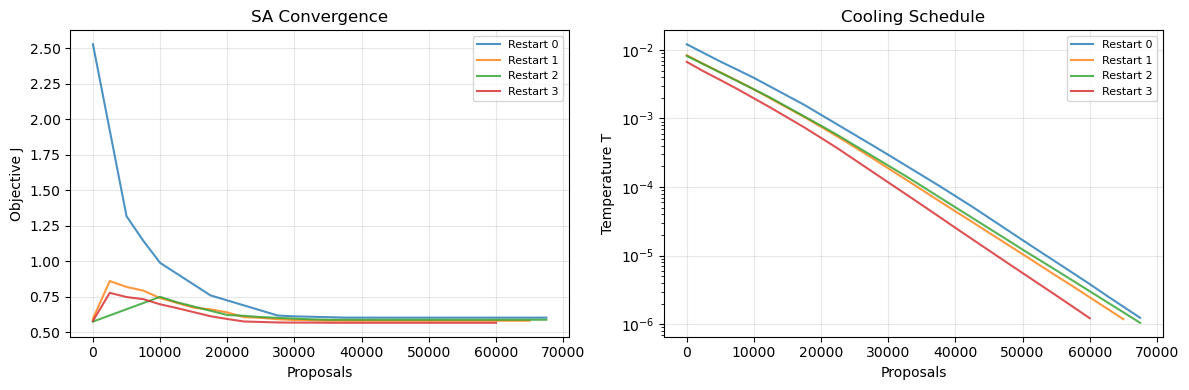

Saved fig_sa_convergence.png


In [14]:
# ── SA convergence plot ───────────────────────────────────────────────────────
log_path = CACHE_DIR / "sa_log.csv"
if log_path.exists():
    log_df = pd.read_csv(log_path)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for restart_id, grp in log_df.groupby("restart"):
        axes[0].plot(grp["proposal"], grp["J"], label=f"Restart {restart_id}", alpha=0.8)
        axes[1].plot(grp["proposal"], grp["T"], label=f"Restart {restart_id}", alpha=0.8)

    axes[0].set(xlabel="Proposals", ylabel="Objective J", title="SA Convergence")
    axes[1].set(xlabel="Proposals", ylabel="Temperature T", title="Cooling Schedule", yscale="log")
    for ax in axes:
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "fig_sa_convergence.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved fig_sa_convergence.png")
else:
    print("No SA log found — run SA loop first")

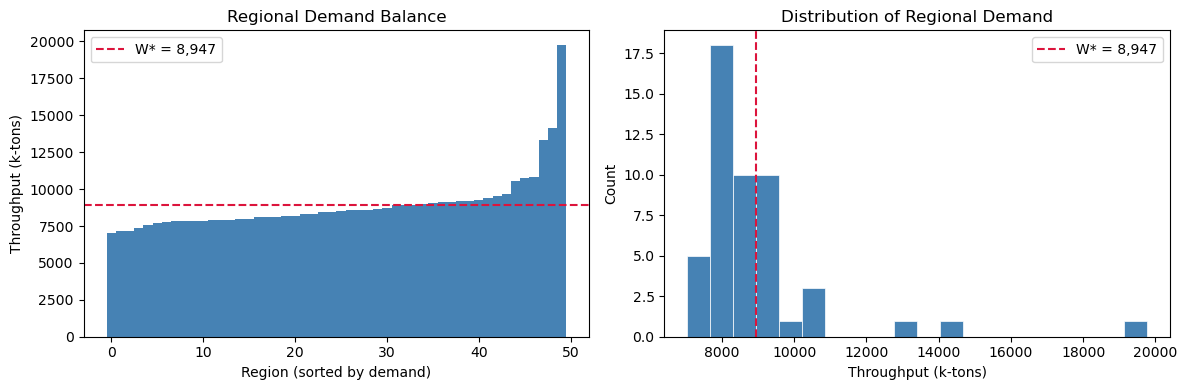

Saved fig_demand_balance.png  (CV=0.227  nRMSE=0.227)


In [15]:
# ── Demand balance plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(K), sorted(r_demand), color="steelblue", width=1.0)
axes[0].axhline(W_star, color="crimson", linestyle="--", linewidth=1.5, label=f"W* = {W_star:,.0f}")
axes[0].set(xlabel="Region (sorted by demand)", ylabel="Throughput (k-tons)",
            title="Regional Demand Balance")
axes[0].legend()

axes[1].hist(r_demand, bins=20, color="steelblue", edgecolor="white", linewidth=0.5)
axes[1].axvline(W_star, color="crimson", linestyle="--", linewidth=1.5, label=f"W* = {W_star:,.0f}")
axes[1].set(xlabel="Throughput (k-tons)", ylabel="Count", title="Distribution of Regional Demand")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_demand_balance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved fig_demand_balance.png  (CV={cv_final:.3f}  nRMSE={nrmse:.3f})")

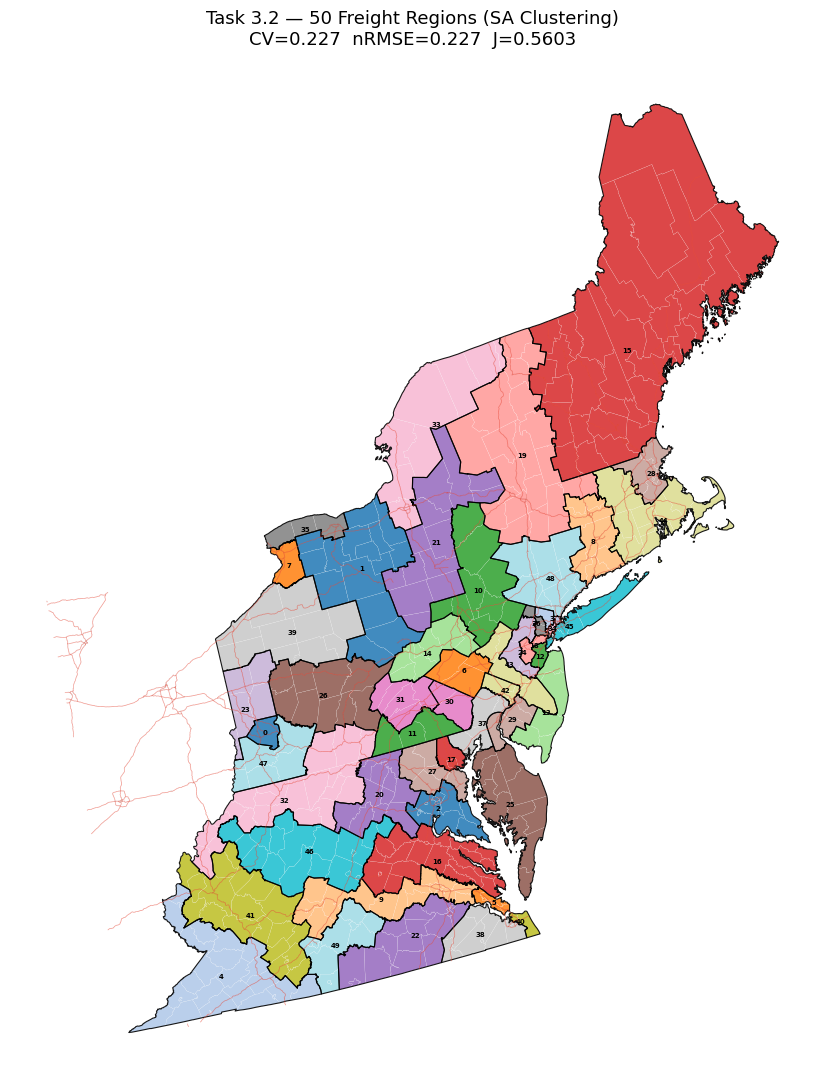

Saved fig_region_map.png


In [16]:
# ── Region choropleth map with interstate overlay ──────────────────────────────
ne_plot = ne.copy()
ne_plot["region_id"] = best_arr

# Dissolve to region polygons for boundary overlay
regions_dissolved = ne_plot.dissolve(by="region_id").reset_index()

fig, ax = plt.subplots(1, 1, figsize=(14, 11))

# Color counties by region
n_colors = K
cmap = plt.get_cmap("tab20", n_colors)
ne_plot.plot(
    column="region_id", ax=ax,
    cmap=cmap, linewidth=0.1, edgecolor="white", alpha=0.85,
)

# Region boundaries
regions_dissolved.boundary.plot(ax=ax, color="black", linewidth=0.8, alpha=0.9)

# Interstate overlay (if available)
int_path = RAW_ROADS_DIR / "North_American_Roads.shp"
if int_path.exists():
    roads_plot = gpd.read_file(int_path, bbox=tuple(ne.to_crs("EPSG:4326").total_bounds))
    roads_plot = roads_plot[(roads_plot["COUNTRY"] == 2) & (roads_plot["CLASS"] == 1)].to_crs(TARGET_CRS)
    roads_plot.plot(ax=ax, color="#e74c3c", linewidth=0.5, alpha=0.6, zorder=3)

# Region centroid labels
for r in range(K):
    if r_counts[r] == 0:
        continue
    ax.text(
        r_cx[r], r_cy[r], str(r),
        fontsize=5, ha="center", va="center",
        color="black", fontweight="bold", zorder=5,
    )

ax.set_axis_off()
ax.set_title(
    f"Task 3.2 — {K} Freight Regions (SA Clustering)\n"
    f"CV={cv_final:.3f}  nRMSE={nrmse:.3f}  J={best_J:.4f}",
    fontsize=13, pad=10,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_region_map.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved fig_region_map.png")

In [17]:
# ── Export final outputs (pandas snapshot layer) ──────────────────────────────

# Per-region activity throughput (for reference; not used in SA objective)
act_arr = ne["throughput"].to_numpy(dtype=np.float64)
r_activity = np.array([act_arr[best_arr == r].sum() for r in range(K)])

# region_assignment.csv — county-level
assign_df = pd.DataFrame({
    "fips": fips_arr,
    "county_name": ne["NAME"].to_numpy(),
    "state": ne["STUSPS"].to_numpy(),
    "region_id": best_arr,
    "external_throughput_ktons": ne["demand_weight"].to_numpy(),
    "activity_throughput_ktons": ne["throughput"].to_numpy(),
})
assign_df.to_csv(OUTPUTS_DIR / "region_assignment.csv", index=False)
print(f"Saved region_assignment.csv  ({len(assign_df)} rows)")

# region_metrics.csv — region-level summary with both demand metrics
metrics_df = pd.DataFrame({
    "region_id": region_ids,
    "n_counties": r_counts,
    "activity_throughput_ktons": r_activity,
    "external_throughput_ktons": r_demand,   # r_demand computed from tp_arr (external)
    "demand_vs_target_pct": (r_demand - W_star) / W_star * 100,
    "centroid_x_m": r_cx,
    "centroid_y_m": r_cy,
    "sse_m2": r_sse,
    "is_connected": [r not in disconnected_regions for r in region_ids],
})
metrics_df.to_csv(OUTPUTS_DIR / "region_metrics.csv", index=False)
print(f"Saved region_metrics.csv  ({len(metrics_df)} rows)")

print(f"\n── Summary ───────────────────────────────")
print(f"  Regions: {K}  |  Counties: 434")
print(f"  Best J:  {best_J:.6f}  (initial: {J_init:.6f})")
print(f"  Demand CV (external): {cv_final:.3f}  |  nRMSE: {nrmse:.3f}")
print(f"  Alignment cut: {align_cut_frac:.4f}")
print(f"  All contiguous: {all_connected}")
print(f"\nNext step: run Task3/recompute_region_external_demand.py")
print(f"  → produces Data/Task3/outputs/region_external_metrics.csv")
print(f"  → fully corrected hub-facing demand excluding same-final-region flows")

Saved region_assignment.csv  (434 rows)
Saved region_metrics.csv  (50 rows)

── Summary ───────────────────────────────
  Regions: 50  |  Counties: 434
  Best J:  0.560323  (initial: 2.528322)
  Demand CV (external): 0.227  |  nRMSE: 0.227
  Alignment cut: 0.3521
  All contiguous: True

Next step: run Task3/recompute_region_external_demand.py
  → produces Data/Task3/outputs/region_external_metrics.csv
  → fully corrected hub-facing demand excluding same-final-region flows
